# 1. Đếm số lượng ảnh train/test

In [1]:
import os
from pathlib import Path

DATASET_PATH = Path("/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_6-digit/test/6-digit_test_img")

dataset_imgs = list(DATASET_PATH.glob("*.*"))
print("Bộ dữ liệu test có: ", len(dataset_imgs))

Bộ dữ liệu test có:  400


In [2]:
DATASET_PATH_2 = Path("/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_6-digit/train/6-digit_train_img")

dataset_imgs = list(DATASET_PATH_2.glob("*.*"))
print("Bộ dữ liệu train có: ", len(dataset_imgs))

Bộ dữ liệu train có:  2555


# 2. Kiểm tra tính trùng lặp ảnh

In [3]:
import hashlib
from collections import defaultdict

def check_duplicates(data_path):
    hash_dict = defaultdict(list)
    for img_path in data_path.glob("*.*"):
        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
            hash_dict[file_hash].append(img_path.name)

    duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

    if duplicates:
        print("Phát hiện các file trùng lặp chính xác:")
        for h, files in duplicates.items():
            print(f"- Nhóm trùng ({h}): {files}")
    else:
        print("Không tìm thấy file nào trùng lặp chính xác.")


In [4]:
check_duplicates(DATASET_PATH)

Không tìm thấy file nào trùng lặp chính xác.


In [5]:
check_duplicates(DATASET_PATH_2)

Không tìm thấy file nào trùng lặp chính xác.


# 3. Visualize ảnh

test257.jpg
/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_6-digit/test/6-digit_test_img/test257.jpg


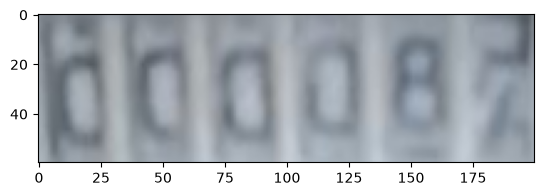

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
data_dict = os.listdir(DATASET_PATH)
print(data_dict[0])

path_img_0 = DATASET_PATH / data_dict[0]
print(path_img_0)

img_0 = Image.open(path_img_0)
plt.imshow(img_0)
plt.show()

# 4. Phân tích csv

In [7]:
import pandas as pd
csv_path = "/Users/mac/MeterReadAI/data/DataBeforeHandle/Word-Wheel_Water_Meter_Dataset/recognition/recognition_6-digit/train/6-digit_train_rec_label_CSV.csv"

df = pd.read_csv(csv_path, header=None)
print(df.head())

            0     1  2  3  4
0  train0.jpg  2340  1  1  1
1  train1.jpg     1  1  1  1
2  train2.jpg  4272  0  1  1
3  train3.jpg  4445  0  0  1
4  train4.jpg  5999  0  0  1
